#Segundo Punto

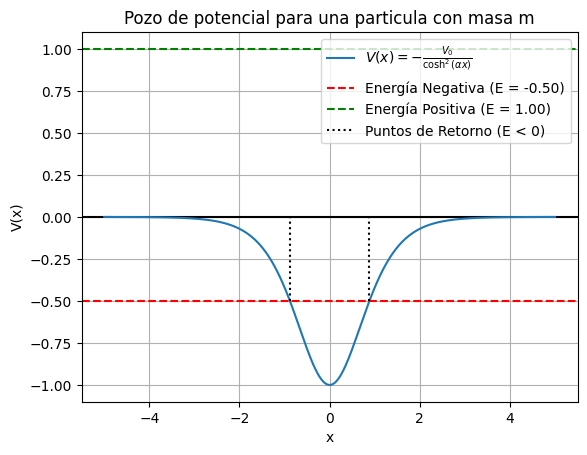

El período T es: 6.2832


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del potencial
V0 = 1.0  # Valor constante de V0
alpha = 1.0  # Valor constante de alpha
m = 1.0  # Masa de la partícula

plt.axhline(0,color='black')
# Función del potencial V(x)
def potential(x, V0, alpha):
    return -V0 / np.cosh(alpha * x)**2

# Valores de x para graficar
x_values = np.linspace(-5, 5, 1000)
V_values = potential(x_values, V0, alpha)

# Graficar el potencial
plt.plot(x_values, V_values, label=r'$V(x) = -\frac{V_0}{\cosh^2(\alpha x)}$')

# Energía total E = T + V
# Para energía negativa, elegimos una velocidad inicial tal que E < 0
v_neg = 1  # Velocidad inicial para energía negativa
E_neg = 0.5 * m * v_neg**2 + potential(0, V0, alpha)  # Energía en x=0

# Para energía positiva, elegimos una velocidad inicial tal que E >= 0
v_pos = 2.0  # Velocidad inicial para energía positiva
E_pos = 0.5 * m * v_pos**2 + potential(0, V0, alpha)  # Energía en x=0

# Graficar las líneas de energía
plt.axhline(E_neg, color='r', linestyle='--', label=f'Energía Negativa (E = {E_neg:.2f})')
plt.axhline(E_pos, color='g', linestyle='--', label=f'Energía Positiva (E = {E_pos:.2f})')


# Puntos de retorno para energía negativa
x_turn_neg = np.arccosh(np.sqrt(V0 / abs(E_neg))) / alpha

# Suponiendo que tu función es V(x), evalúala en los puntos de retorno
y_turn_pos = -V0 / np.cosh(alpha * x_turn_neg)**2
y_turn_neg = -V0 / np.cosh(alpha * (-x_turn_neg))**2

# Dibujamos las líneas punteadas desde el valor de y hasta y=0
plt.plot([x_turn_neg, x_turn_neg], [y_turn_pos, 0], color='black', linestyle=':', label='Puntos de Retorno (E < 0)')
plt.plot([-x_turn_neg, -x_turn_neg], [y_turn_neg, 0], color='black', linestyle=':')


# Esto mantiene el resto de tu gráfica sin cambios



# Configuración de la gráfica
plt.xlabel('x')
plt.ylabel('V(x)')
plt.title('Pozo de potencial para una particula con masa m')

plt.legend()
plt.grid(True)
plt.show()


#Periodo del movimiento finito:

from scipy.integrate import quad

# Parámetros del sistema
E = E_neg # Energía total (debe ser negativa para movimiento finito)

# Límites de integración (puntos de retorno)
u1 = -x_turn_neg
u2 = x_turn_neg

# Función a integrar
def integrand(u, E, V0):
    return np.cosh(u) / np.sqrt(E * np.cosh(u)**2 + V0)

# Evaluación numérica de la integral
T, _ = quad(integrand, u1, u2, args=(E, V0))
T *= (2 / alpha) * np.sqrt(m / 2)  # Factor adicional

print(f"El período T es: {T:.4f}")